In [1]:
from itu.algs4.graphs.digraph import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gzip
import powerlaw

## 1. Sobre o grafo
Os **vértices** representam páginas de [Stanford University](https://Stanford.edu) (Stanford.edu), e as **arestas direcionadas** representam links entre elas.

| **Dataset info** |  | |
| --- | --- | --- |
| Vértices — $V$ | 281903 | |
| Arestas — $E$ | 2312497 | direcionadas |
| Tipo de grafo | ? | |
| Densidade — $\rho$ | 0.0000291 | esparso |
| Grau médio (in/out) — $d(G)$ | 8.20 | |

## 2. Leitura do arquivo
O arquivo contendo a lista de arestas é carregado em .txt.gz <br>
As primeiras linhas incluem comentários nos quais são identificados o número de vértices e arestas do grafo.
```
# Directed graph (each unordered pair of nodes is saved once): web-Stanford.txt 
# Stanford web graph from 2002
# Nodes: 281903 Edges: 2312497
# FromNodeId	ToNodeId
```
As linhas seguintes contêm as arestas no formato: vertice1 vertice2

In [2]:
def load_graph_from_file(file_path):
    with gzip.open(file_path, 'rt') as f:
        # Ler as linhas do arquivo
        lines = f.readlines()
        
        # Ignorar as linhas de comentário e extrair o número de vértices e arestas
        for line in lines:
            if line.startswith('#'):
                if 'Nodes:' in line and 'Edges:' in line:
                    parts = line.split()
                    v = int(parts[2])
                    E = int(parts[4])
                    break
        
        # criar Dataframe para armazenar as arestas
        edges = []
        for line in lines:
            if not line.startswith('#'):
                parts = line.split()
                if len(parts) == 2:
                    v1 = int(parts[0])
                    v2 = int(parts[1])
                    edges.append((v1, v2))
        df_edges = pd.DataFrame(edges, columns=['Source', 'Target'])


        # Criar um grafo dirigido com o número de vértices
        G = Digraph(v, first_index=min(df_edges['Source']))
        
        # Adicionar as arestas ao grafo
        for line in lines:
            if not line.startswith('#'):
                parts = line.split()
                if len(parts) == 2:
                    v1 = int(parts[0])
                    v2 = int(parts[1])
                    G.add_edge(v1, v2)
    
    return G, df_edges

G, df_edges = load_graph_from_file('./files/web-Stanford.txt.gz')
in_degrees = [G.in_degree(v) for v in range(min(df_edges['Source']), G.V() + min(df_edges['Source']))]
out_degrees = [G.out_degree(v) for v in range(min(df_edges['Source']), G.V() + min(df_edges['Source']))]

print(f"Número de vértices: {G.V()}")
print(f"Número de arestas: {G.E()}")
print(f"Multigrafo: {is_multi_digraph(G, min(df_edges['Source']))}")

Número de vértices: 281903
Número de arestas: 2312497
Multigrafo: False


## 3. Salvar arquivo em .csv e lista de in-degree/out-degree
O arquivo carregado é salvo em formato .csv compatível com o software Gephi. <br>
As listas do grau (in-degree, out-degree) por vértice são salvas para análise de distribuição.

In [23]:
# Salvar o DataFrame em um arquivo CSV
df_edges.to_csv('./files/edges.csv', index=False)

# Salvar lista de in-degrees e out-degrees
pd.DataFrame({'In-Degree': in_degrees, 'Out-Degree': out_degrees}).to_csv('./files/degrees.csv', index=False)

## 4. Densidade
Encontrada a partir da fórmula:
$ \ \rho = \frac{E}{V(V-1)} $ 
<br>
Onde $ \rho \rightarrow 1 $ indica um grafo **denso**; <br>
E $ \rho \rightarrow 0 $ indica um grafo **esparso**.

In [24]:
print(f"Densidade: {G.density():.9f}")

Densidade: 0.000029099


## 5. Distribuição de graus

In [ ]:
max_in_degree = max(in_degrees)
max_out_degree = max(out_degrees)

min_in_degree = min(in_degrees)
min_out_degree = min(out_degrees)

avg_in_degree = sum(in_degrees) / len(in_degrees)
avg_out_degree = sum(out_degrees) / len(out_degrees)

print("="*20)
print(f"max in-degree: {max_in_degree}\nmin in-degree: {min_in_degree}")
print(f"avg in-degree: {avg_in_degree:.2f}")
print("="*20)
print(f"max out-degree: {max_out_degree}\nmin out-degree: {min_out_degree}")
print(f"avg out-degree: {avg_out_degree:.2f}")
print("="*20)

# in_degree_variance = np.var(in_degrees)
# out_degree_variance = np.var(out_degrees)
# print(f"variância in-degree: {in_degree_variance:.2f}")
# print(f"variância out-degree: {out_degree_variance:.2f}")

max in-degree: 38606
min in-degree: 0
avg in-degree: 8.20
max out-degree: 255
min out-degree: 0
avg out-degree: 8.20


### 5.1. Histograma

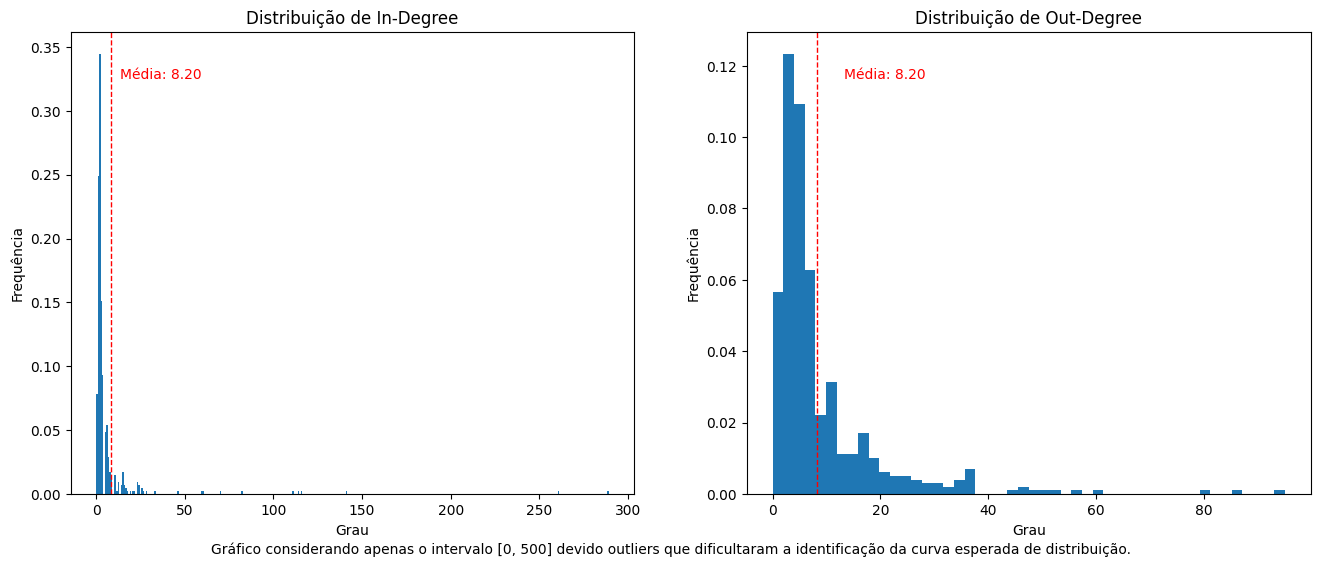

In [39]:
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.hist(in_degrees[:500], bins="fd", density=True)
plt.title("Distribuição de In-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_in_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_in_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_in_degree:.2f}', color='red')

plt.subplot(1,2,2)
plt.hist(out_degrees[:500], bins="fd", density=True)
plt.title("Distribuição de Out-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_out_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_out_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_out_degree:.2f}', color='red')

plt.figtext(0.5, 0.01, "Gráfico considerando apenas o intervalo [0, 500] devido outliers que dificultaram a identificação da curva esperada de distribuição.", ha="center")

plt.show()

### 5.2. Gráfico de dispersão

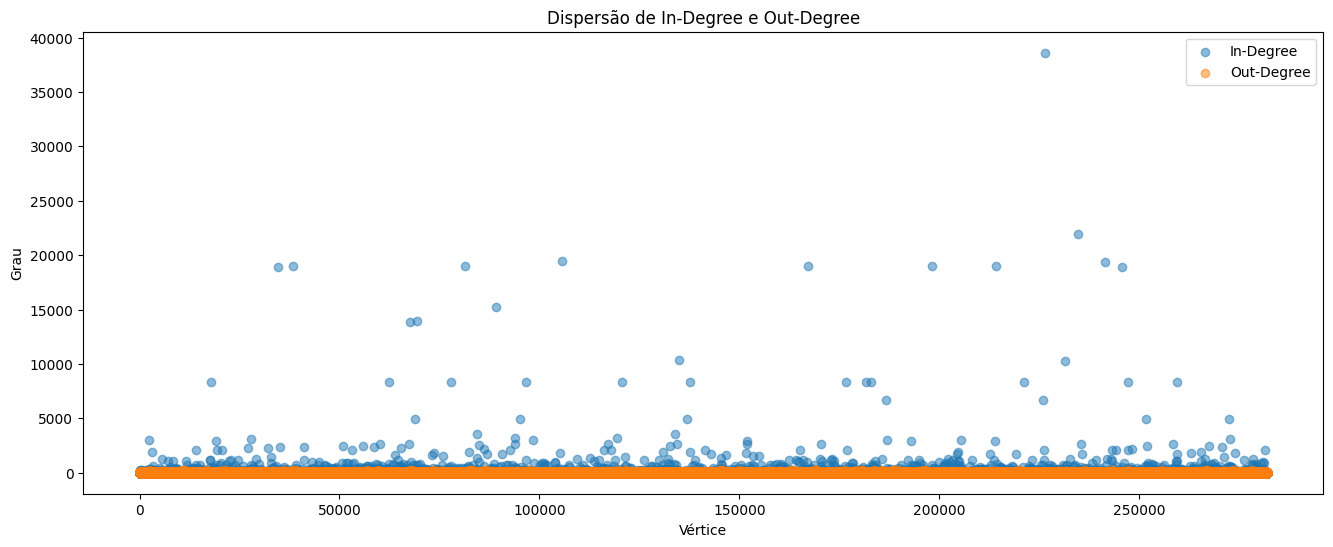

In [42]:
# plotar dispersão de graus
plt.figure(figsize=(16,6))

plt.scatter(range(len(in_degrees)), in_degrees, alpha=0.5, label="In-Degree")
plt.scatter(range(len(out_degrees)), out_degrees, alpha=0.5, label="Out-Degree")
plt.title("Dispersão de In-Degree e Out-Degree")
plt.xlabel("Vértice")
plt.ylabel("Grau")
plt.legend()

plt.show()

### 5.3. Ajuste a Power Law / Log Normal

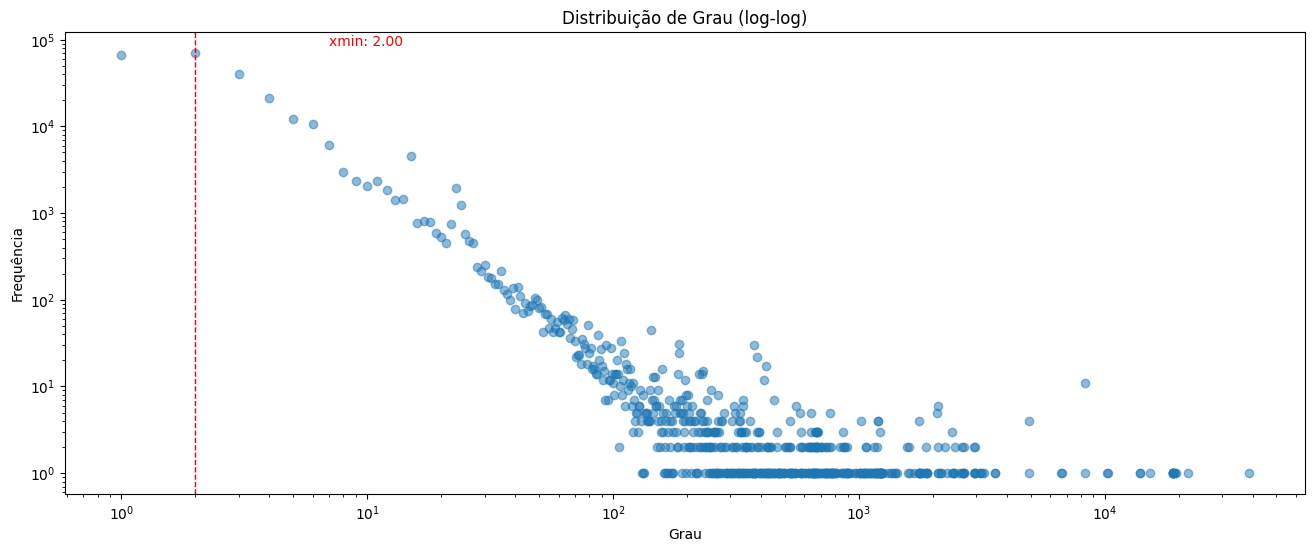

In [48]:
degree_count = np.bincount(in_degrees) # freq de cada grau
degrees = np.arange(len(degree_count)) # array de graus correspondente aos índices do degree_count

plt.figure(figsize=(16,6))
plt.loglog(degrees[degree_count > 0], degree_count[degree_count > 0], marker="o", linestyle="None", alpha=0.5)
# destacar xmin
plt.text(results.power_law.xmin + 5, plt.ylim()[1]*0.7, f'xmin: {results.power_law.xmin:.2f}', color='red')
plt.title("Distribuição de Grau (log-log)")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(results.power_law.xmin, color='red', linestyle='dashed', linewidth=1)
plt.show()

teste:

In [56]:
results = powerlaw.Fit(in_degrees, xmin=2)
print(results.power_law.alpha)
print(results.power_law.xmin)

2.3996378469287873
2.0


resultados:

In [53]:
R, p = results.distribution_compare('power_law', 'lognormal')
print(R) 
print(f"{p:.12f}") 

32.02446296822134
0.000000000000


### 5.4. Interpretação dos resultados

Os números impressos na célula anterior são:

- `alpha` e `xmin` vêm do objeto `results.power_law`. `alpha` é o expoente da lei de potência ajustada, ou seja, o parâmetro que determina a inclinação na escala log‑log. Valores típicos para redes reais ficam entre 2 e 3. `xmin` é o grau mínimo a partir do qual a lei de potência foi considerada pelo ajuste; dados abaixo desse valor são ignorados no cálculo do `alpha`.

- `R` é o **logaritmo da razão de verossimilhança** (log likelihood ratio) entre os dois modelos comparados. É o valor que indica qual modelo tem verossimilhança maior.
- `p` é o **p‑value** associado ao teste de razão de verossimilhança. Ele quantifica quão provável é observar um `R` tão extremo sob a hipótese nula de que ambos os modelos descrevem igualmente bem os dados.
- `R` e `p` são retornados por `results.distribution_compare('power_law', 'lognormal')`.
  - `R` é o logaritmo da razão de verossimilhança entre os dois modelos. Um valor **positivo** indica que os dados são mais compatíveis com a lei de potência do que com a lognormal; um valor **negativo** favoreceria a lognormal. No seu caso `R ≈ 0.206` aponta uma leve preferência pela potência.
  - `p` é a probabilidade de obter uma diferença de verossimilhança tão extrema (ou mais) sob a hipótese nula de que *ambos* os modelos são igualmente bons. Um `p` pequeno (tipicamente < 0.05) significa que a preferência medida em `R` não é apenas ruído estatístico; aqui você tem `p ≈ 9e-05`, indicando que a vantagem da potência não é aleatória.

Em resumo, os valores obtidos sugerem que a distribuição de graus **segue melhor uma lei de potência** do que uma lognormal, com expoente `alpha` (veja saída acima) e um ponto de corte `xmin` acima do qual a fitting foi feito. A escolha final sempre deve considerar o contexto do problema e inspeção visual do ajuste (plot log‑log).  

<!-- Se quiser comparar com outros candidatos (ex.: exponencial), basta passar o nome desejado para `distribution_compare`. -->